
****************************************
Model: Logistic Regression
Confusion Matrix:
 [[733 300]
 [ 78 296]]

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



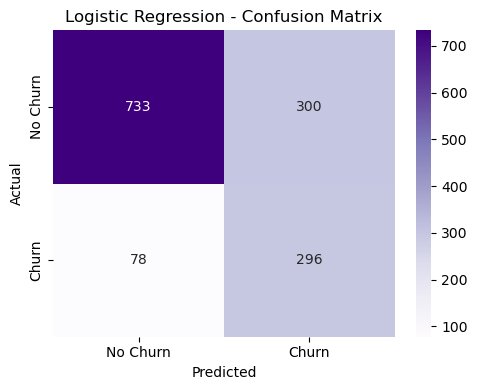


****************************************
Model: Random Forest
Confusion Matrix:
 [[937  96]
 [210 164]]

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.63      0.44      0.52       374

    accuracy                           0.78      1407
   macro avg       0.72      0.67      0.69      1407
weighted avg       0.77      0.78      0.77      1407



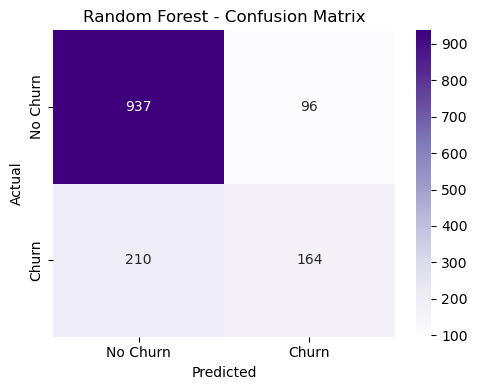


****************************************
Model: Gradient Boosting
Confusion Matrix:
 [[932 101]
 [195 179]]

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



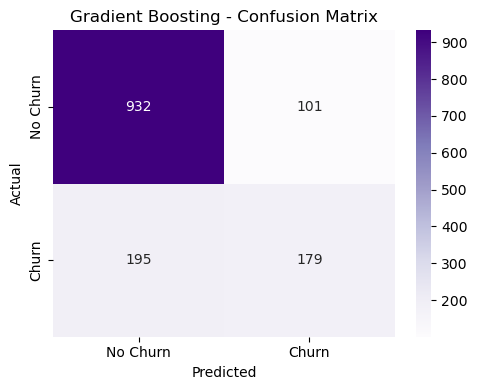

In [ ]:
import pandas as pd
import numpy as np
#import joblib
from google.colab import drive
drive.mount('/content/drive')
from google.colab import files
uploaded = files.upload()
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
#Load + clean data
#df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

df = pd.read_csv('Telco-Customer-Churn-rawdata.csv')
df = df.replace(r'^\s*$', np.nan, regex=True)
df = df.drop(['customerID'], axis=1)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df[df['tenure'] != 0]
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


#Feature engineering
df['AvgCharges'] = df['TotalCharges'] / df['tenure']
df['AvgCharges'] = df['AvgCharges'].fillna(0)

#Split features/target
X = df.drop('Churn', axis=1)
y = df['Churn']

#Define column types
num_cols = ['tenure','MonthlyCharges','TotalCharges' ]
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()

#Build pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000,class_weight='balanced'))
])


# Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# train
pipeline.fit(X_train, y_train)
models = {"Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42) }

#evaluate prediction
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

results = {}
best_model = None
best_score = 0
best_recall = 0

for name, model in models.items():
    print(f"\n{'*'*40}")
    print(f"Model: {name}")
    
    # Create pipeline for each model
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        "confusion_matrix": cm,
        "accuracy": accuracy,
        "recall": recall,
        "f1_score": f1
    }
    
    # Track best model
    if f1 > best_score:
        best_score = f1
        best_model = name
        best_recall = recall
    
    # Print metrics
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, 
                annot=True, 
                fmt='d', 
                cmap='Purples',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# Print best model
print("\n" + "="*40)
print(f"Best Performing Model: {best_model}")
print(f"Best F1 Score: {best_score:.4f}")
print(f"Recall Score: {best_recall:.4f}")
print("="*40)

#key insights
#Overall Model Performance
# Logistic Regression performed best in terms of recall (79%), it correctly identified most customers who actually churned. 
# This is important because minimizing missed churn cases (false negatives) is critical in customer retention scenarios.
# Random Forest and Gradient Boosting achieved higher precision (63% and 64%), meaning their churn predictions were more accurate when they did predict churn, 
# but they missed a larger portion of actual churners (higher false negatives).
    
